In [1]:
# === Cell 1: imports & path setup ===
import sys
from pathlib import Path

# notebook is in: <repo>/code/notebooks
# repo root is: <repo>
ROOT = Path.cwd().resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
print("sys.path[0]:", sys.path[0])

import numpy as np
import matplotlib.pyplot as plt

from macml.src.graphs.generators import make_default_graphs
from macml.src.algorithms.admm_shared import admm_shared_quadratic
from macml.src.algorithms.admm_edge import admm_edge_quadratic

print("Imports OK ✅")


ROOT: /home/ilya/Projects/mixed-affine-constraints-ml
sys.path[0]: /home/ilya/Projects/mixed-affine-constraints-ml
Imports OK ✅


In [2]:
# === Cell 2: toy HFL data ===
np.random.seed(42)

n = 60   # agents
d = 5    # dimension

b = np.random.randn(n, d) * 2.0  # local targets b_i
x_star = b.mean(axis=0)

print("n, d =", n, d)
print("||x_star|| =", np.linalg.norm(x_star))


n, d = 60 5
||x_star|| = 0.2595245319706292


In [3]:
# === Cell 3: ADMM (shared-variable formulation) ===
rho = 1.0
steps = 200

opt_err_s, cons_err_s, x_s, z_s, u_s = admm_shared_quadratic(
    b=b,
    rho=rho,
    steps=steps,
)

print("Shared ADMM:")
print(" final opt_err =", opt_err_s[-1])
print(" final cons_err =", cons_err_s[-1])


Shared ADMM:
 final opt_err = 5.723536526344588e-14
 final cons_err = 9.166616660951354e-13


In [4]:
# === Cell 4: ADMM (edge-based formulation) ===
G = make_default_graphs(n)["Ring"]

feas_err_e, cons_err_e, x_e, u_e = admm_edge_quadratic(
    G=G,
    b=b,
    rho=rho,
    steps=steps,
)

print("Edge ADMM:")
print(" final feas_err =", feas_err_e[-1])
print(" final cons_err =", cons_err_e[-1])


Edge ADMM:
 final feas_err = 0.028939365170318778
 final cons_err = 0.2813361086009406


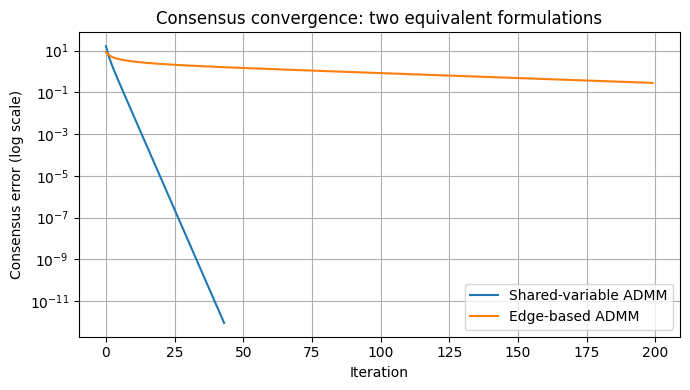

In [5]:
# === Cell 5: convergence comparison ===
plt.figure(figsize=(7, 4))

plt.semilogy(cons_err_s, label="Shared-variable ADMM")
plt.semilogy(cons_err_e, label="Edge-based ADMM")

plt.xlabel("Iteration")
plt.ylabel("Consensus error (log scale)")
plt.title("Consensus convergence: two equivalent formulations")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(ROOT / "assets" / "iter2_shared_vs_edge_ring.png", dpi=200)
plt.show()
